In [23]:
from pystac_client import Client
import rasterio
from rasterio.windows import from_bounds
from rasterio.merge import merge
from pyproj import Transformer
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import psutil
import os 
from dotenv import load_dotenv
load_dotenv()

True

# Modelos Digitais de Elevação - Digital Elevation Model (DEM)

Os modelo digital de elevação é uma representação digital da altitude da superfície terrestre, em que cada célula do grid contém um valor de elevação. Ele normalmente é utilizado para análises de declives, relevos para projetos de infraestrutura bem como planejamento urbano. Muito utilizado também dentro da hidrologia para escoamento das águas, bacias hidrográficas e análise de riscos de inundação. 

Utilizaremos o DEM do Copernicus, que é um DEM produzido principalmente a partir de dados de radar obtidos pela missão espacial TanDEM-X, da Airbus/DLR. Os satélites adquiriram imagens radar da superfície terrestre de diferentes posições; através de interferometria radar (InSAR) foi possível calcular a altitude dos pontos da superfície. Esses dados foram depois processados, corrigidos e editados para gerar uma superfície de elevação contínua. O resultado é disponibilizado, entre outras resoluções, a 30 m (GLO-30) e 90 m (GLO-90).

Uma importante consideração é que o Copernicus DEM representa um modelo digital de superfície  (Digital Surface Model (DSM)) e não o modelo digital do terreno (Digital Terrain Model) onde este sim representaria a altitude de cada ponto sem contar a utilização da superfície. Dessa forma, o DSM do Copernicus pode incluir altura de edificios, altura de árvores e outras estruturas, apesar de suas correções que melhorar a qualidade do modelo, a remoção sistemática desses artefatos não é feita, pois o modelo visa representar a superfície terrestre, diferentemente de representar o terreno em si.  

### Chaves de API de acesso.

Para baixarmos os rasters referente a nossa análise, precisamos primeiro ter registrado uma chave api no CDSE. Olhe a última aula com a explicação de como criar essa chave. 

In [2]:
#os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_ACCESS_KEY_ID"] = os.environ.get("CDSE_CLIENT")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ.get("CDSE_SECRET")
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"

# endpoint da AWS pro ecossistema copernicus no STAC
cdse_stac = "https://stac.dataspace.copernicus.eu/v1/"
client = Client.open(cdse_stac)

### Acessando a coleção através do STAC

In [3]:
client.get_collection('cop-dem-glo-30-dged-cog')

<CollectionClient id=cop-dem-glo-30-dged-cog>

### Delineando uma bbox de interesse

Aqui vamos analisar a área entre do litoral de São Paulo, famoso pela serra do mar e pelas clássicas fotos que vemos por aí nas mídias sociais. 

![alt text](<imagens/Screenshot 2026-09-03 at 13.30.13.png>)


In [19]:
## minha bbox para cubatao
bbox = [-46.80215, -24.10, -46.158748, -23.754701]

In [11]:
import folium
from shapely.geometry import box

bounds_polygon = box(*bbox)

centro_lat = (bbox[1] + bbox[3]) / 2
centro_lon = (bbox[0] + bbox[2]) / 2

m = folium.Map(location=[centro_lat, centro_lon], zoom_start=10)


folium.GeoJson(
    bounds_polygon.__geo_interface__,
    name="Bounds",
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'blue',
        'weight': 3,
        'fillOpacity': 0
    }
).add_to(m)

m

### Acessando o catálogo de imagens

In [26]:
dem = client.search(
    collections=["cop-dem-glo-30-dged-cog"],
    bbox=bbox
)

In [27]:
for item in dem.items():
    print(item)

<Item id=Copernicus_DSM_COG_10_S25_00_W047_00_DEM>
<Item id=Copernicus_DSM_COG_10_S24_00_W047_00_DEM>


In [28]:
# Collect the two DEM assets
dem_paths = [
    item.assets["data"].href
    for item in dem.items()
]

In [29]:
dem_paths

['s3://eodata/auxdata/CopDEM_COG/copernicus-dem-30m/Copernicus_DSM_COG_10_S25_00_W047_00_DEM/Copernicus_DSM_COG_10_S25_00_W047_00_DEM.tif',
 's3://eodata/auxdata/CopDEM_COG/copernicus-dem-30m/Copernicus_DSM_COG_10_S24_00_W047_00_DEM/Copernicus_DSM_COG_10_S24_00_W047_00_DEM.tif']

In [42]:


# Open the DEMs as Rasterio datasets
srcs = [rasterio.open(path) for path in dem_paths]

try:
    # CRS of the DEMs
    dem_crs = srcs[0].crs

    # Transform bbox from EPSG:4326 to DEM CRS
    transformer = Transformer.from_crs(
        "EPSG:4326",
        dem_crs,
        always_xy=True
    )

    minx, miny = transformer.transform(bbox[0], bbox[1])
    maxx, maxy = transformer.transform(bbox[2], bbox[3])

    # Merge the two DEM tiles and clip to bbox
    mosaic, mosaic_transform = merge(
        srcs,
        bounds=(minx, miny, maxx, maxy),
        masked=True
    )

    # Remove the band dimension
    dem_array = mosaic[0]

finally:
    # Close the datasets
    for src in srcs:
        src.close()

print("Shape:", dem_array.shape)
print("CRS:", dem_crs)
print("Transform:", mosaic_transform)



Shape: (1243, 2316)
CRS: EPSG:4326
Transform: | 0.00, 0.00,-46.80|
| 0.00,-0.00,-23.75|
| 0.00, 0.00, 1.00|


In [45]:
dem_array

masked_array(
  data=[[757.687744140625, 758.630126953125, 758.8342895507812, ...,
         734.3363647460938, 737.7005615234375, 733.650634765625],
        [761.6920166015625, 759.5462646484375, 759.8544921875, ...,
         735.8826904296875, 737.18115234375, 737.0667724609375],
        [764.2097778320312, 760.8612670898438, 761.0741577148438, ...,
         734.8046264648438, 736.7730102539062, 736.5520629882812],
        ...,
        [8.038652420043945, 5.4134016036987305, 6.642546653747559, ...,
         --, --, --],
        [6.919680118560791, 6.8587799072265625, 6.9172043800354, ..., --,
         --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  

# Visualizando o DEM

Temos um array com a elevação de Cubatão/SP (base da Serra do Mar) — a região vai de quase o nível do mar até mais de 1.100 m, numa distância bem curta, por causa da escarpada. Isso vai deixar as curvas de nível bem interessantes de ver.

Vamos criar dois tipos de visualização:
1. Um mapa de elevação simples (cada cor = uma altura);
2. Um relevo sombreado (hillshade), que simula a luz do sol vindo de um ângulo para destacar o relevo.

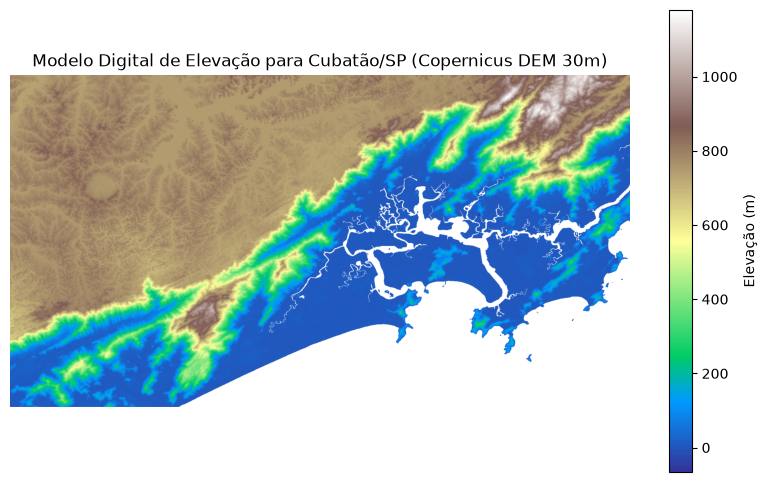

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(dem_array, cmap="terrain")
fig.colorbar(im, ax=ax, label="Elevação (m)")
ax.set_title("Modelo Digital de Elevação para Cubatão/SP (Copernicus DEM 30m)")
ax.axis("off")
plt.show()

## Características de Modelos Digitais de Elevação

Aqui conseguimos calcular alguns padroes como hillshade, angulo de inclinação, declive, e aspecto do terreno, que é basicamente para qual direção do globo aquela face do terreno está apontando.

Isso pode ser extremamente útil quando estamos pensando em termos de planejamento. Exemplo: Você está analisando um terreno de um comprador que gostaria de construir o quarto da casa virado para a face Norte. Para estabelecer curvas de níveis precisamos também dessas características, bem como para análise hidrológicas. 

Aqui vai um detalhe mega importante que já tratamos nas outras aulas. SISTEMA DE COORDENADAS. Esse DEM está em `EPSG:4326` (graus, não metros)(Sistema Geográfica não projetado). Para o sombreado ficar com as proporções certas, precisamos converter o tamanho do pixel de graus para metros antes de calcular a inclinação, isso é, projetar para o UTM da nossa área de investigação. 

In [ ]:
mosaic_transform.

Affine(0.0002777777777777778, 0.0, -46.80215,
       0.0, -0.0002777777777777778, -23.754701)

In [57]:
import xarray as xr
import rioxarray  

# pegamos o numero de colunas e linhas 
rows, cols = dem_array.shape

## transformamos cada coluna e linha dado a transformacao affine do CRS
## essa soma do 0.5 visa mudar a posicao do canto esquerdo para o centro de cada pixel
## pense que um pixel de raster esta na coordenada 100 em seu canto superior esquerdo e esse pixel tem 30m de largura
## entao para movermos para o meio, precisamos somar com 15m, ou 0.5 vezes o tamanho original do pixel.
xs = mosaic_transform.c + (np.arange(cols) + 0.5) * mosaic_transform.a
ys = mosaic_transform.f + (np.arange(rows) + 0.5) * mosaic_transform.e

# vamos criar um XARRAY para utilizar as funções já existentes 
dem_da = xr.DataArray(
    np.ma.filled(dem_array, np.nan),
    dims=("y", "x"),
    coords={"y": ys, "x": xs},
    name="elevation",
)
# Aqui ordenamos o CRS que esta em 4326 - WGS84
dem_da = dem_da.rio.write_crs(dem_crs)

# xarray tem funcoes uteis para estiamr o CRS, apesar de podermos reprojetar na mao também. 
utm_crs = dem_da.rio.estimate_utm_crs()
dem_utm = dem_da.rio.reproject(utm_crs)
dem_utm.rio.write_nodata(np.nan, inplace=True)

print("CRS estimado:", utm_crs)
print("shape:", dem_utm.shape, "| resolução (m):", dem_utm.rio.resolution())

CRS estimado: EPSG:32723
shape: (1349, 2284) | resolução (m): (28.85130642918404, -28.85130642918404)


In [56]:
xs

array([-46.80201111, -46.80173333, -46.80145556, ..., -46.15951111,
       -46.15923333, -46.15895556], shape=(2316,))

# Análise Espacial de Modelos Digitais de Elevação

Uma vez que temos nossos dados em xarray e projetados, podemos prosseguir com essas análises de uma maneira muito fácil e simplificada. Poderíamos também fazer esses mesmo calculos em numpy, contudo, é muito mais trabalhoso e suscetível a erros.

A biblioteca [`xarray-spatial`](https://xarray-spatial.org/) já traz essas funções prontas, testadas e otimizadas. Xarray nada mais é do que um numpy array com nomes, coordenadas e metadados associados, criando um cubo tri ou quadridimensional (x,y,z,time) para qualquer variável. Xarray nos permite ter coleções de dados com muitas e muitas variáveis, como é o caso do dataset ERA5, que contém muito dados climáticos em um só dataset.

Vamos nos aprofundar em xarray na semana que vem, mas hoje teremos uma breve introdução e como essa biblioteca funciona. 

Vamos ver três análises clássicas de terreno: **hillshade**, **slope** (inclinação) e **aspect** (orientação).

A ideia é para cada pixel, calculamos primeiro a inclinação (slope) e depois a direção do declive (aspect) do terreno. Por fim imitamos a iluminação do sol dado um ângulo de azimute e altura escolhido. 



```Só por curiosidade, vamos ver como calcular todas as funções que o xarray proporciona em numpy, e depois realizar o mesmo em Xarray!```

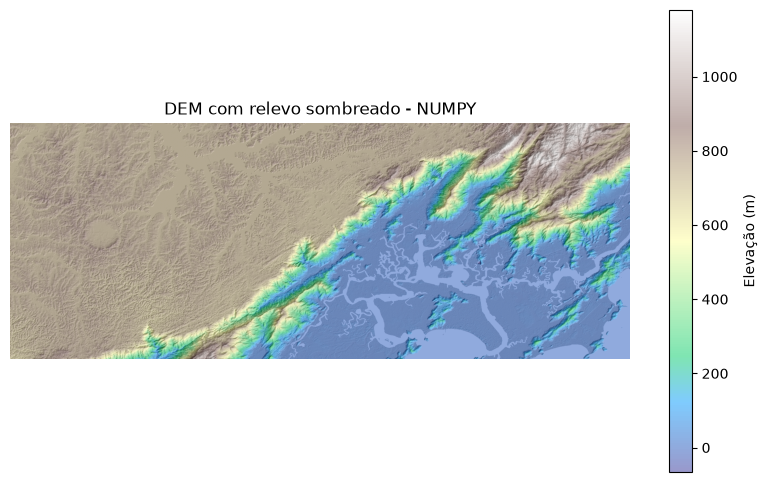

In [59]:
def hillshade(array, azimuth=315, angle_altitude=45, 
              cellsize_x=30, cellsize_y=30
              ):
    """Calcula um relevo sombreado a partir de um DEM."""
    data = np.ma.filled(array, np.nan).astype("float64")
    dy, dx = np.gradient(data, cellsize_y, cellsize_x)
    slope = np.pi / 2 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)

    azimuth_rad = np.radians(360 - azimuth + 90)
    altitude_rad = np.radians(angle_altitude)

    shaded = (np.sin(altitude_rad) * np.sin(slope)
              + np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect))
    return np.clip(shaded, 0, 1)


# resolução nominal do Copernicus DEM 30m. 1 arco-segundo (graus) > metros
resolucao_graus = 1 / 3600
lat_media = (bbox[1] + bbox[3]) / 2
cellsize_y = resolucao_graus * 111_320
cellsize_x = resolucao_graus * 111_320 * np.cos(np.radians(lat_media))

shade = hillshade(dem_array, cellsize_x=cellsize_x, cellsize_y=cellsize_y)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(shade, cmap="gray")
im = ax.imshow(dem, cmap="terrain", alpha=0.5)
fig.colorbar(im, ax=ax, label="Elevação (m)")
ax.set_title("DEM com relevo sombreado - NUMPY")
ax.axis("off")
plt.show()

## Slope (inclinação)

Slope mede o quão **íngreme** é o terreno em cada pixel, em graus onde `0°` é totalmente plano, `90°` seria uma parede vertical. É uma das métricas mais usadas em geomorfologia como risco de deslizamento, erosão, dificuldade de uma trilha, viabilidade de construção, tudo depende da inclinação do terreno.

/Users/macuser/Documents/UN/ebook/.venv/lib/python3.13/site-packages/xrspatial/utils.py:1184: RuntimeWarning: All-NaN slice encountered
  mins.append(np.nanmin(win))
/Users/macuser/Documents/UN/ebook/.venv/lib/python3.13/site-packages/xrspatial/utils.py:1185: RuntimeWarning: All-NaN slice encountered
  maxs.append(np.nanmax(win))


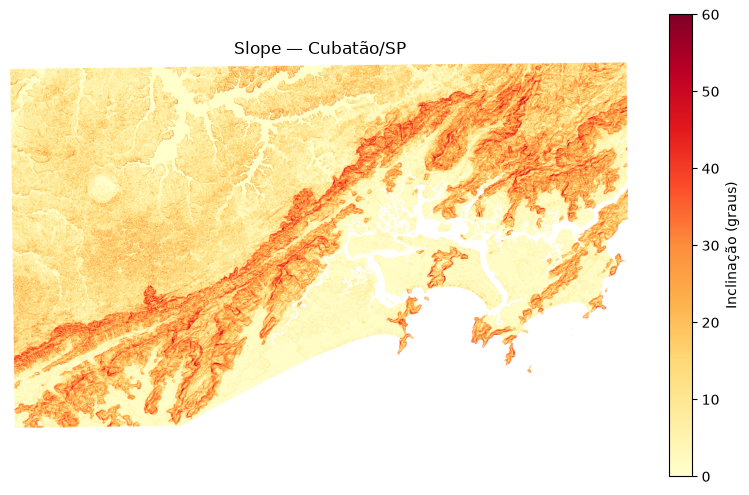

Inclinação média: 12.2°  |  máxima: 67.6°


In [64]:
from xrspatial import slope as xrs_slope

slope_da = xrs_slope(dem_utm)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(slope_da, cmap="YlOrRd", vmin=0, vmax=60)
fig.colorbar(im, ax=ax, label="Inclinação (graus)")
ax.set_title("Slope — Cubatão/SP")
ax.axis("off")
plt.show()

print(f"Inclinação média: {float(slope_da.mean()):.1f}°  |  máxima: {float(slope_da.max()):.1f}°")

## Aspect (orientação)

Aspect indica **para que direção a encosta está voltada**. Vai de 0° a 360°, como uma bússola (0°/360° = Norte, 90° = Leste, 180° = Sul, 270° = Oeste). É importante porque, no hemisfério sul, encostas voltadas para o norte recebem mais sol ao longo do ano (e as voltadas para o sul, menos), afetando o ambiente tais como vegetação, umidade do solo, e até microclima. Um terreno que é perfeitamente plano teoricamente não teria uma direção definida e a biblioteca marca esses pixels com `-1`.

Como aspect "dá a volta" (0° e 360° são a mesma direção), usamos um colormap cíclico em vez de um linear.

/Users/macuser/Documents/UN/ebook/.venv/lib/python3.13/site-packages/xrspatial/utils.py:1184: RuntimeWarning: All-NaN slice encountered
  mins.append(np.nanmin(win))
/Users/macuser/Documents/UN/ebook/.venv/lib/python3.13/site-packages/xrspatial/utils.py:1185: RuntimeWarning: All-NaN slice encountered
  maxs.append(np.nanmax(win))


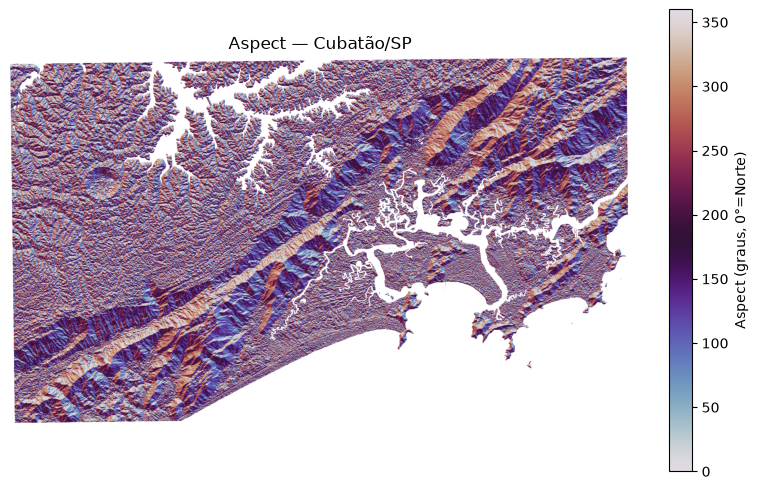

In [65]:
from xrspatial import aspect as xrs_aspect

aspect_da = xrs_aspect(dem_utm)
aspect_plot = aspect_da.where(aspect_da >= 0)  # esconde os pixels planos (-1) do mapa

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(aspect_plot, cmap="twilight", vmin=0, vmax=360)
fig.colorbar(im, ax=ax, label="Aspect (graus, 0°=Norte)")
ax.set_title("Aspect — Cubatão/SP")
ax.axis("off")
plt.show()

## Hillshade

Mesmo calculo de antes, mas com a implementação pronta da biblioteac. Simulamos a luz do sol vindo de um azimute e altura escolhidos.

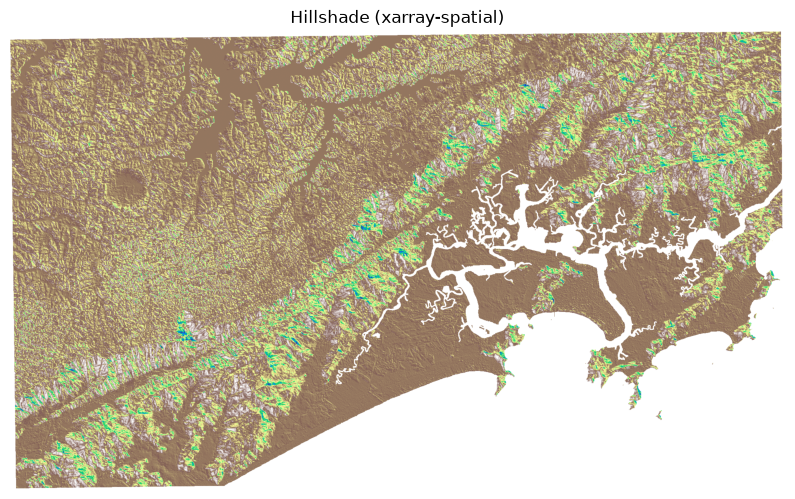

In [63]:
from xrspatial import hillshade as xrs_hillshade

shade_xrs = xrs_hillshade(dem_utm, 
                          azimuth=315, 
                          angle_altitude=45)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(shade_xrs, cmap="terrain")
ax.set_title("Hillshade (xarray-spatial)")
#fig.colorbar(im, ax=ax, label="Elevação (m)")
ax.axis("off")
plt.show()

# Curvas de nível (contour lines)

Uma curva de nível conecta todos os pontos com a **mesma elevação**. Vamos gerar curvas a cada 100 metros, o mesmo intervalo que vamos usar mais adiante quando transformarmos essas curvas em vetores.

Por enquanto isso é só uma visualização (o matplotlib calcula as curvas em cima do array, em coordenadas de pixels que ainda não são objetos vetoriais georreferenciados). Na próxima etapa vamos extrair essas mesmas curvas como geometrias vetoriais.

In [70]:
intervalo = 100  # metros

nivel_min = np.floor(dem_array.min()/intervalo) *intervalo
nivel_max = np.ceil(dem_array.max()/intervalo) *intervalo 

niveis = np.arange(nivel_min, nivel_max + intervalo, intervalo)
print("Níveis (m):", niveis)

Níveis (m): [-100.    0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1000.
 1100. 1200.]


Níveis (m): [-100.    0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1000.
 1100. 1200.]


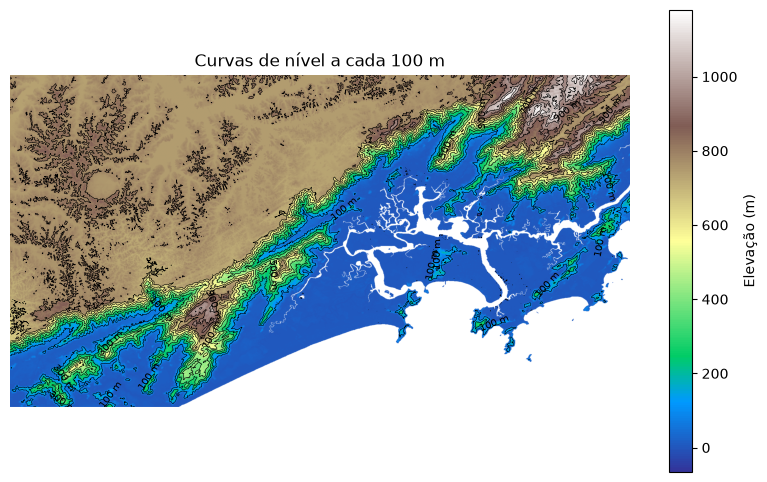

In [72]:
intervalo = 100  # metros

nivel_min = np.floor(dem_array.min()/intervalo) *intervalo
nivel_max = np.ceil(dem_array.max()/intervalo) *intervalo 

niveis = np.arange(nivel_min, nivel_max + intervalo, intervalo)
print("Níveis (m):", niveis)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(dem_array, cmap="terrain")
fig.colorbar(im, ax=ax, label="Elevação (m)")

contornos = ax.contour(dem_array, levels=niveis, colors="black", linewidths=0.4)
# só rotula a cada 200 m (de 100 em 100 fica ilegível no platô, onde o relevo é mais suave)
ax.clabel(contornos, levels=niveis[::2], inline=True, fontsize=7, fmt="%d m")

ax.set_title(f"Curvas de nível a cada {intervalo} m")
ax.axis("off")
plt.show()

In [76]:
len(contornos.allsegs)

14

# Vetorizando: curvas de nível como GeoDataFrame

As curvas que acabamos de desenhar existem só dentro do objeto do matplotlib (`contornos`) as quais são ótimas para visualizar, mas não servem para nada além de visualização. Se quisermos aplicar todas as análises espaciais as quais já temos conhecimento, precisamos vetorizar essas linhas. 

A ideia aqui é simples: o matplotlib já calculou, para cada nível, uma ou mais linhas — cada uma como uma lista de pontos em **coordenadas de pixel** (`cs.allsegs`). Nós só precisamos:

1. Pegar esses pontos (coluna, linha);
2. Converter para coordenadas reais (x, y) usando a `dem_transform` que guardamos;
3. Montar uma `LineString` do `shapely` para cada segmento;
4. Guardar tudo num `GeoDataFrame`, com a elevação como uma coluna normal.

A partir daí, cada curva de nível vira uma linha "de verdade" — dá pra fazer `gdf.intersects(ponto)`, `gdf.length`, salvar em disco, etc.

In [78]:
import geopandas as gpd
from shapely.geometry import LineString
from rasterio.transform import xy as transform_xy


def contours_to_geodataframe(contour_set, transform, crs) -> gpd.GeoDataFrame:
    """Converte um QuadContourSet do matplotlib em um GeoDataFrame de linhas (uma por segmento)."""
    geometries = []
    elevations = []

    for level, segments in zip(contour_set.levels, contour_set.allsegs):
        for seg in segments:
            if len(seg) < 2:
                continue  # precisa de pelo menos 2 pontos pra formar uma linha
            cols, rows = seg[:, 0], seg[:, 1]
            xs, ys = transform_xy(transform, rows, cols)  # pixel para coordenadas reais
            geometries.append(LineString(zip(xs, ys)))
            elevations.append(level)

    return gpd.GeoDataFrame({"elevation": elevations}, geometry=geometries, crs=crs)


contornos_gdf = contours_to_geodataframe(contornos, mosaic_transform, dem_crs)
print(f"{len(contornos_gdf)} segmentos de curva de nível")
contornos_gdf.head()

2221 segmentos de curva de nível


,elevation,geometry
0,0.0,"LINESTRING (-46.35629 -23.92051, -46.35618 -23..."
1,0.0,"LINESTRING (-46.2872 -23.92123, -46.28729 -23...."
2,0.0,"LINESTRING (-46.35646 -23.92132, -46.35619 -23..."
3,0.0,"LINESTRING (-46.34866 -23.92178, -46.3486 -23...."
4,0.0,"LINESTRING (-46.31978 -23.92428, -46.31979 -23..."


In [79]:
contornos_gdf['elevation'].unique()

array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,
        900., 1000., 1100.])

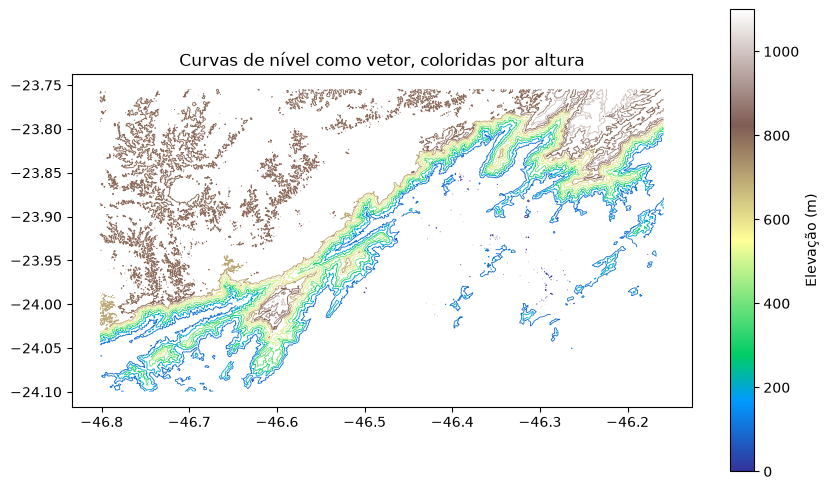

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
contornos_gdf.plot(column="elevation", 
                   cmap="terrain", 
                   legend=True,
                    legend_kwds={"label": "Elevação (m)"}, 
                    linewidth=0.6, 
                    ax=ax)
ax.set_title("Curvas de nível como vetor, coloridas por altura")
ax.set_aspect("equal")
plt.show()



A partir do momento que vetorizamos esse raster, podemos aplicar qualquer analise espacial que ja conhecemos

In [92]:
from shapely import Point
# Exemplo: Vamos achar todas as curvas a menos de 200 metros do centroid de um ponto

# pra consultas com distância em metros, reprojetamos pra um CRS métrico
contornos_gdf_utm = contornos_gdf.to_crs(contornos_gdf.estimate_utm_crs())

# ponto exemplo: -23.85, -46.7
ponto_exemplo = gpd.GeoDataFrame(geometry=[Point(-46.7,-23.85)],crs="4326").to_crs(contornos_gdf_utm.crs)
ponto = ponto_exemplo.geometry.iloc[0]

curvas_proximas = contornos_gdf_utm[contornos_gdf_utm.geometry.distance(ponto) < 500]
print(f"{len(curvas_proximas)} segmentos de curva a menos de 200 m do ponto de exemplo")
# é exatamente esse tipo de consulta espacial que vamos usar depois para
# cruzar pontos (ex: nascentes, trilhas) com a curva de nível mais próxima

2 segmentos de curva a menos de 200 m do ponto de exemplo


In [93]:
curvas_proximas

,elevation,geometry
1266,800.0,"LINESTRING (327012.225 7361058.891, 327040.404..."
1267,800.0,"LINESTRING (326673.066 7361024.435, 326701.424..."


# Modelo Digital de Elevação em 3D

Vamos usar `plotly.graph_objects.Surface`, que já renderiza como uma superfície 3D interativa (dá pra rotacionar, dar zoom e passar o mouse pra ver a elevação exata) sem precisar de nenhuma biblioteca 3D pesada.

Dois truques para visualização em 3 dimensões:
- A grade tem muitos pixels (centenas de milhares), por isso vamos reduzir a amostragem (`::3`) só pra manter a interação fluida no navegador, para uma imagem final de alta qualidade, poderíamos usar a resolução completa. Caso seu computador ainda demore, tente reduzir a amostragem ainda mais. 
- Nossa área é bem mais larga do que alta (dezenas de km de largura, ~1 km de desnível) e caso plotarmos na escala real, o relevo pareceria quase liso. Por isso aplicamos uma **exageração vertical**, uma prática comum em visualização de terreno.

In [94]:
import plotly.graph_objects as go

step = 3  # amostragem pra manter a interação fluida
dem_sample = dem_utm.values[::step, ::step]

x_res, y_res = dem_utm.rio.resolution()
x_extent = dem_sample.shape[1] * abs(x_res) * step
y_extent = dem_sample.shape[0] * abs(y_res) * step
z_extent = float(np.nanmax(dem_sample) - np.nanmin(dem_sample))

exagero_vertical = 3
aspect_z = (z_extent / x_extent) * exagero_vertical

fig = go.Figure(data=[go.Surface(z=dem_sample, colorscale="earth",
                                  colorbar=dict(title="m"))])
fig.update_layout(
    title=f"DEM 3D — Cubatão/SP (exagero vertical {exagero_vertical}x)",
    scene=dict(
        xaxis_title="x (amostrado)",
        yaxis_title="y (amostrado)",
        zaxis_title="Elevação (m)",
        aspectmode="manual",
        aspectratio=dict(x=1, y=y_extent / x_extent, z=aspect_z),
    ),
    width=900, height=600,
)
fig.show()

# Operações para análises Hidrológicas

### Delineação de bacias hidrográficas (watershed)

Aos amantes de hidrologia, ou amantes da [água que bebemos](https://youtu.be/zkCkIGqGyAI?t=62), podemos pensar em bacias hidrográficas como delineação de toda a área de contribuição cuja água do ciclo hidrólogico passará por um determinado ponto, sendo esse ponto o exutório (pour point), o exutório final das bacias hidrográficas é na grande maioria dos casos o mar, contudo a diferente localização de um exutório pode delinear diferentes bacias hidrógraficas. 

O pipeline clássico de hidrologia de terreno é sempre parecido:

1. **Preencher depressões**: Os DEMs possuem sempre dados faltantes, devido a (ruído/erro de medição) que prendem o fluxo de água num loop infinito. Precisamos "encher" esses buracos antes de continuar.
2. **Direção de fluxo (flow direction)** — para cada pixel, calculamos para qual dos 8 vizinhos a água escorreria (o vizinho com a maior queda de altitude)? Isso é o método D8.
3. **Fluxo acumulado (flow accumulation)** — para cada pixel, quantos pixels "rio acima" desembocam nele? Pixels com fluxo acumulado alto são, por definição, onde os rios estão.
4. **Delineação da bacia** — a partir de um ponto de saída, "andamos rio acima" seguindo as direções de fluxo e marcamos toda a área que contribui pra aquele ponto.

Vamos usar o [`pysheds`](https://mattbartos.com/pysheds/), a biblioteca Python mais usada especificamente pra isso.

In [95]:
# o pysheds ainda usa `np.in1d`, que foi removido do numpy 2.x (virou `np.isin`).
# esse "remendo" resolve a incompatibilidade sem precisar trocar de versão do numpy.
if not hasattr(np, "in1d"):
    np.in1d = np.isin

from pysheds.grid import Grid

O `pysheds` lê de um arquivo raster no disco (não de um array em memória), então vamos exportar o `dem_utm` (o mesmo tipo de exportação que já fizemos antes) e carregar a partir dele.

In [96]:
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
dem_utm_path = os.path.join(output_dir, "cubatao_dem_utm.tif")
dem_utm.rio.to_raster(dem_utm_path)

grid = Grid.from_raster(dem_utm_path)
dem_grid = grid.read_raster(dem_utm_path)
print("grid shape:", grid.shape, "| crs:", grid.crs.srs if hasattr(grid.crs, "srs") else grid.crs)

grid shape: (1349, 2284) | crs: PROJCS["WGS 84 / UTM zone 23S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-45],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32723"]]


## Condicionando o DEM e calculando direção/acúmulo de fluxo

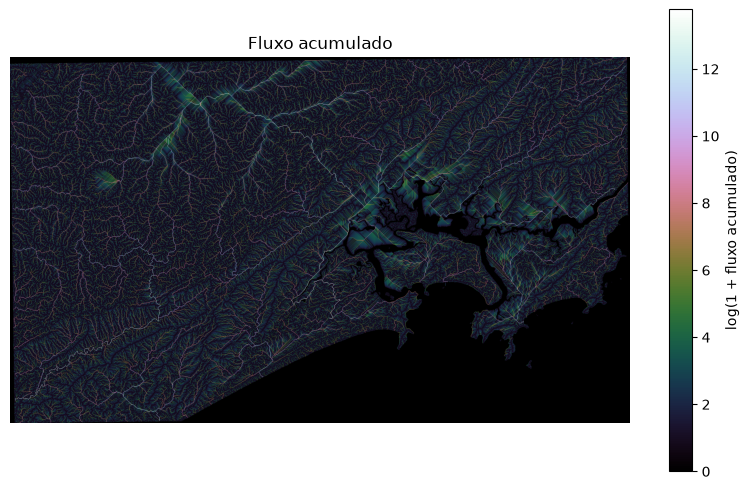

In [97]:
# 1. preenche buracos e "pits" isolados
pit_filled_dem = grid.fill_pits(dem_grid)
flooded_dem = grid.fill_depressions(pit_filled_dem)
inflated_dem = grid.resolve_flats(flooded_dem)

# 2. direção de fluxo (D8: 8 direções possíveis por pixel)
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

# 3. fluxo acumulado
acc = grid.accumulation(fdir, dirmap=dirmap)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(np.log1p(acc), cmap="cubehelix")
fig.colorbar(im, ax=ax, label="log(1 + fluxo acumulado)")
ax.set_title("Fluxo acumulado")
ax.axis("off")
plt.show()

## Escolhendo um exutório e delineando a bacia

Precisamos escolher um ponto de saída pra "cortar" a bacia. Pra garantir que caímos em cima de um rio de verdade (e não no meio de um morro), vamos usar o pixel com **maior fluxo acumulado** de toda a nossa área, por definição, ali passa mais água do que em qualquer outro lugar da nossa grade.

> Numa aplicação real, você normalmente escolheria esse ponto manualmente (ex: onde fica uma estação fluviométrica, ou a foz de um rio específico) e usaria `grid.snap_to_mask` pra "encaixar" as coordenadas escolhidas em cima do pixel de rio mais próximo.

Ponto de saída escolhido: (350235, 7344724) | fluxo acumulado: 961366 pixels
Área da bacia: 800.2 km²  (961366 pixels)


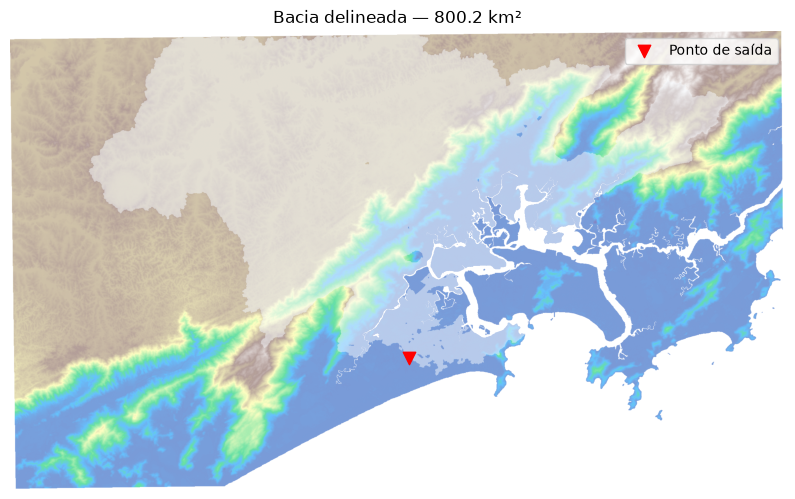

In [98]:
row_pour, col_pour = np.unravel_index(np.argmax(acc), acc.shape)
x_pour, y_pour = grid.affine * (col_pour, row_pour)
print(f"Ponto de saída escolhido: ({x_pour:.0f}, {y_pour:.0f}) | fluxo acumulado: {acc.max():.0f} pixels")

catchment = grid.catchment(x=x_pour, y=y_pour, fdir=fdir, dirmap=dirmap, xytype="coordinate")

cellsize = abs(grid.affine[0])
area_km2 = catchment.sum() * (cellsize ** 2) / 1e6
print(f"Área da bacia: {area_km2:.1f} km²  ({catchment.sum()} pixels)")
# repare: o número de pixels da bacia é EXATAMENTE o fluxo acumulado no ponto de saída —
# não é coincidência, é a própria definição de fluxo acumulado!

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(dem_utm, cmap="terrain", alpha=0.6)
ax.imshow(np.where(catchment, 1, np.nan), cmap="Blues", alpha=0.5)
ax.scatter([col_pour], [row_pour], color="red", marker="v", s=80, label="Ponto de saída")
ax.set_title(f"Bacia delineada — {area_km2:.1f} km²")
ax.legend()
ax.axis("off")
plt.show()

## Vetorizando a bacia e extraindo a rede de rios

Por fim, dois produtos vetoriais a partir dessa análise:

1. O **polígono** da bacia (`grid.polygonize()`), pra virar um `GeoDataFrame`, igual fizemos com as curvas de nível;
2. A **rede de drenagem** (os rios), extraída diretamente do DEM a partir de um limiar de fluxo acumulado. Tentamos também puxar hidrografia do OpenStreetMap (via `osmnx`) pra comparar, mas o servidor Overpass não estava acessível a partir daqui — então ficamos só com a rede derivada do próprio DEM, que já é uma fonte de dado hidrográfico legítima (é basicamente assim que produtos como o HydroSHEDS são gerados). Poderíamos tentar puxar a rede da ANA (Agência Nacional de Águas) mas ainda não existe uma biblioteca em python para fazer isso automaticamente *(FICA AI A DICA PARA UM GRANDE PROJETO FINAL)*

Durante as pesquisas achei um github meio desatualizado que faz mais ou menos o papel: [HydroBR](https://github.com/wallissoncarvalho/hydrobr/tree/refactor). Interessante essa ferramenta aqui mas olhem como os dados estao disponibilizados: [RainData](https://raindata.streamlit.app/) que vem desse artigo aqui [A Computational Platform for Exploring Brazilian Rainfall Data](https://www.mdpi.com/2306-5729/11/9/232)


Bacia: 12 polígono(s), área = 800.2 km²
Rede de rios: 2610 trechos


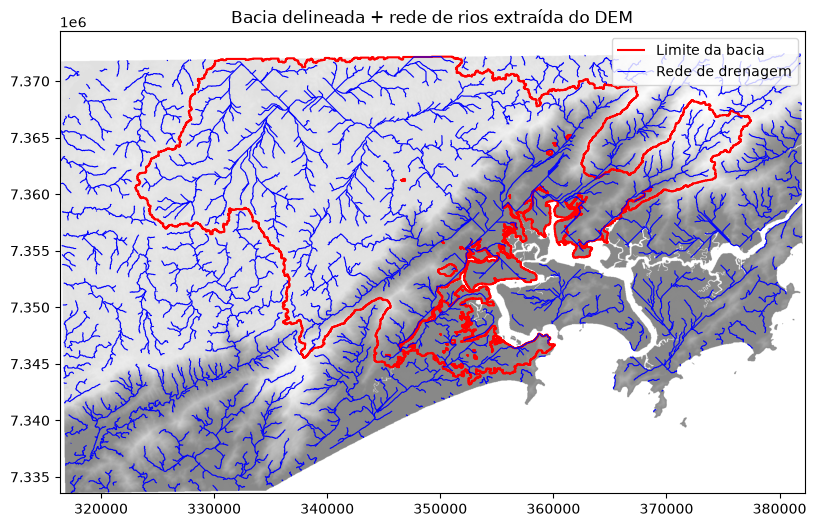

In [99]:
from shapely.geometry import shape as shapely_shape

# 1. bacia como polígono
shapes = list(grid.polygonize(data=catchment.astype("int32"), mask=catchment))
bacia_gdf = gpd.GeoDataFrame(
    geometry=[shapely_shape(geom) for geom, _ in shapes],
    crs=grid.crs,
)
print(f"Bacia: {len(bacia_gdf)} polígono(s), área = {bacia_gdf.geometry.area.sum() / 1e6:.1f} km²")

# 2. rede de rios: qualquer pixel com fluxo acumulado acima de um limiar vira "rio"
limiar_rio = 500  # em número de pixels contribuindo (500 px * ~28x28m ≈ 0.4 km² de área de captação)
branches = grid.extract_river_network(fdir, acc > limiar_rio, dirmap=dirmap)

rios_gdf = gpd.GeoDataFrame.from_features(branches["features"], crs=grid.crs)
print(f"Rede de rios: {len(rios_gdf)} trechos")

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(dem_utm, cmap="Greys_r", alpha=0.5,
          extent=[dem_utm.x.min(), dem_utm.x.max(), dem_utm.y.min(), dem_utm.y.max()])
bacia_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5, label="Limite da bacia")
rios_gdf.plot(ax=ax, color="blue", linewidth=0.8, label="Rede de drenagem")
ax.set_title("Bacia delineada + rede de rios extraída do DEM")
ax.legend()
plt.show()

# Bonus! 

E se misturarmos diferentes rasters que conseguimos acessar através do STAC e transformarmos em diferentes tipos de dados para visualizações interativas? 

Aqui nesse próximo exemplo, vamos usar dados do Sentinel-2 com os dados de DEM para gerarmos um point-cloud. Point-cloud são um "novo" tipo de dados de nuvem de pontos que estão ganhando bastante tração nos últimos anos com avanços de tecnologias como o Lidar. Basicamente esses sensores permitem milhares de pontos sejam lançados no ambiente que está sendo medido e são o padrão ouro para muito tipo de análises como mensuração de biomassa, carros autônomos utilizam esses dados para navegação bem como robos autônomos. 

Dessa forma, quando mesclamos dados de Sentinel-2 com os modelos digitais de elevação conseguimos interpolar e reproduzir 'artificialmente' essa nuvem de pontos para criarmos visualizações poderosas.

Curioso, dê uma olhada nesse [repo](https://github.com/emanuel-gf/EO-Point-Cloud) aqui que ensina como fazer. 

![alt text](imagens/gif_image.gif)